# Building the NLA Amplitude One Factor at a Time

The previous notebook used **PyCCL** to define a cosmology and calculate the matter
power spectrum. This notebook focuses on the multiplicative factors that control the
signed nonlinear-alignment (NLA) amplitude $\mathcal A_{\rm IA}$. Studying them
separately makes their physical roles, limiting behavior, and parameter degeneracies
easier to understand.

## The path through the notebook

By the end, you should be able to:

- explain why a tidal gravitational field can influence galaxy orientations;
- distinguish the linear-alignment and nonlinear-alignment prescriptions;
- decompose the NLA amplitude into cosmological, redshift, luminosity, and scale factors;
- interpret every parameter from plots of its individual factor;
- verify the normalization and asymptotic limits of the phenomenological extensions.

The workflow continues in two separate notebooks: `POWER.ipynb` combines the factors
and constructs IA power spectra, while `SAMPLE.ipynb` samples the model parameters and
builds amplitude datasets.

The luminosity and scale-dependent extensions introduced here are deliberately
**phenomenological**. They are useful for teaching and flexible forward modelling, but
they do not replace a survey-calibrated luminosity model or the TATT framework.

---

## Why galaxies can become intrinsically aligned

A galaxy forms inside the cosmic web. Gravity does not pull equally strongly in every
direction: nearby matter can stretch the local gravitational environment more along one
direction than another. This directional stretching is called the **tidal field**.

A simple intrinsic-alignment hypothesis is:

> The coherent part of a galaxy's intrinsic shape responds to the surrounding tidal field.

We summarize that response with the signed IA amplitude $\mathcal A_{\rm IA}$:

$$
\text{intrinsic shape}
\approx
\mathcal A_{\rm IA}
\times
\text{matter tidal field}.
$$

If the matter field has power spectrum $P_{\rm m}$, this response produces

$$
P_{\delta I}(k,z)
=
\mathcal A_{\rm IA}(k,z)P_{\rm m}(k,z),
\qquad
P_{II}(k,z)
=
\mathcal A_{\rm IA}^2(k,z)P_{\rm m}(k,z).
$$

- $P_{\delta I}$ correlates matter density with intrinsic galaxy shape.
- $P_{II}$ correlates two intrinsic-shape fields.

Under the sign convention used here, positive $A_0$ gives
$\mathcal A_{\rm IA}<0$ and therefore $P_{\delta I}<0$, while $P_{II}$ remains
non-negative.

### From linear alignment to nonlinear alignment

In the **linear-alignment (LA)** model, the IA amplitude multiplies the linear matter
power spectrum:

$$
P_{\delta I}^{\rm LA}
=
\mathcal A_{\rm IA}P_{\rm lin},
\qquad
P_{II}^{\rm LA}
=
\mathcal A_{\rm IA}^2P_{\rm lin}.
$$

The **nonlinear-alignment (NLA)** prescription keeps the same amplitude structure but
replaces the linear spectrum with the nonlinear matter spectrum:

$$
P_{\delta I}^{\rm NLA}
=
\mathcal A_{\rm IA}P_{\rm nl},
\qquad
P_{II}^{\rm NLA}
=
\mathcal A_{\rm IA}^2P_{\rm nl}.
$$

NLA is a useful empirical baseline rather than a complete theory of nonlinear galaxy
formation. More advanced models, such as TATT, introduce additional tidal-field terms.

---

## Decompose the NLA amplitude

We separate the signed amplitude into

$$
\boxed{
\mathcal A_{\rm IA}(k,z\mid\boldsymbol\Omega,\boldsymbol\Theta)
=
-A_0\,\mathcal A_\Omega(z\mid\boldsymbol\Omega)\,
\mathcal A_\Theta(k,z\mid\boldsymbol\Theta)
}
$$

with

$$
\boxed{
\mathcal A_\Omega(z\mid\boldsymbol\Omega)
=
C_0\frac{\Omega_m}{D(z\mid\boldsymbol\Omega)}
}
$$

and the explicitly factorized model component

$$
\boxed{
\mathcal A_\Theta(k,z\mid\boldsymbol\Theta)
=
R_z(z;\eta,z_\ast)\,
R_L(z;\xi,s,z_q,z_\ast)\,
S(k,z;q,n^\ast,k_t^\ast,\alpha,m,\gamma_t,\gamma_n).
}
$$

The common pivot coordinate is

$$
\boxed{r_\ast(z)=\frac{1+z}{1+z_\ast}},
\qquad r_\ast(z_\ast)=1,
$$

and the model-dependent parameter vector is

$$
\boldsymbol\Theta
=
(\eta,\xi,s,z_q,q,n^\ast,k_t^\ast,\alpha,m,\gamma_t,\gamma_n).
$$

| Component | Role |
|---|---|
| $A_0$ | Overall nuisance normalization |
| $\mathcal A_\Omega$ | Standard cosmological density and growth scaling |
| $R_z$ | Explicit phenomenological redshift factor, $R_z=r_\ast^\eta$ |
| $R_L$ | Smooth luminosity-population evolution |
| $S(k,z)$ | Joint nonlinear scale and redshift response |

We normalize $R_z(z_\ast)=R_L(z_\ast)=1$ and design $S(k\ll k_t,z)\to1$.
These conventions keep the factors interpretable before recombination in
`POWER.ipynb`.

---

## Set up the calculation

We use NumPy for numerical arrays, PyCCL for cosmological growth, and Matplotlib for
visualization. The tested factor implementations live in `Alignment.py`, which is the
single implementation shared by all three notebooks.

In [1]:
import json
import sys
from pathlib import Path

import numpy
import pyccl
from matplotlib import pyplot

In [2]:
pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 25,
    "text.usetex": True,
})

In [3]:
base_path = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()
code_path = base_path / "Code"
data_path = base_path / "Data"

if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

print("Project directory:", base_path)
print("Code directory:   ", code_path)
print("Data directory:   ", data_path)

Project directory: /Users/s2227120/Downloads/IAFlowCloud
Code directory:    /Users/s2227120/Downloads/IAFlowCloud/Code
Data directory:    /Users/s2227120/Downloads/IAFlowCloud/Data


In [ ]:
from Alignment import (
    Z_STAR,
    NLAModel,
    cosmological_factor,
    luminosity_factor,
    pivot_redshift_ratio,
    redshift_factor,
    scale_transition,
)

### Fix the cosmology and redshift grid

We keep the cosmology fixed so that changes in the following plots can be attributed to
one IA factor at a time. The parameters are read from `Planck.json`, and CAMB supplies
the transfer function and nonlinear matter prescription used by PyCCL.

PyCCL expects scale factor rather than redshift in its growth functions, so every
redshift array is converted using $a=1/(1+z)$.

In [5]:
with open(data_path / "Planck.json", "r", encoding="utf-8") as file:
    parameter = json.load(file)

print(parameter)

{'H': 0.6731999996749277, 'W0': -1.0, 'WA': 0.0, 'NS': 0.966, 'AS': 2.101e-09, 'MNU': 0.06, 'TCMB': 2.7255, 'NEFF': 3.0440016274835076, 'SIGMA8': 0.812, 'OMEGAM': 0.314419, 'OMEGAB': 0.04939, 'OMEGAC': 0.265029, 'OMEGAD': 0.68408, 'OMEGAN': 0.0014214549162596109, 'OMEGAR': 7.973409482179201e-05, 'OMEGAK': -1.8901108145286116e-07}


In [6]:
cosmology = pyccl.cosmology.Cosmology(
    h=parameter["H"],
    w0=parameter["W0"],
    wa=parameter["WA"],
    A_s=parameter["AS"],
    n_s=parameter["NS"],
    m_nu=parameter["MNU"],
    T_CMB=parameter["TCMB"],
    Omega_k=parameter["OMEGAK"],
    Omega_c=parameter["OMEGAC"],
    Omega_b=parameter["OMEGAB"],
    mass_split="normal",
    transfer_function="boltzmann_camb",
    extra_parameters={
        "camb": {
            "kmax": 100,
            "lmax": 5000,
            "halofit_version": "mead2020_feedback",
            "HMCode_logT_AGN": 7.8,
        }
    },
)

In [7]:
z1 = 0.0
z2 = 3.0
z_size = 10
z_grid = numpy.linspace(z1, z2, z_size)

---

## Standard cosmological scaling

The conventional NLA amplitude contains

$$
\boxed{
\mathcal A_\Omega(z)
=
C_0\frac{\Omega_m}{D(z)}.
}
$$

Here $D(z)$ is the linear growth factor normalized to $D(0)=1$ and
$C_0\simeq0.0134$ is the conventional IA normalization. Because structure is less
developed at higher redshift, $D(z)$ decreases and $1/D(z)$ increases.

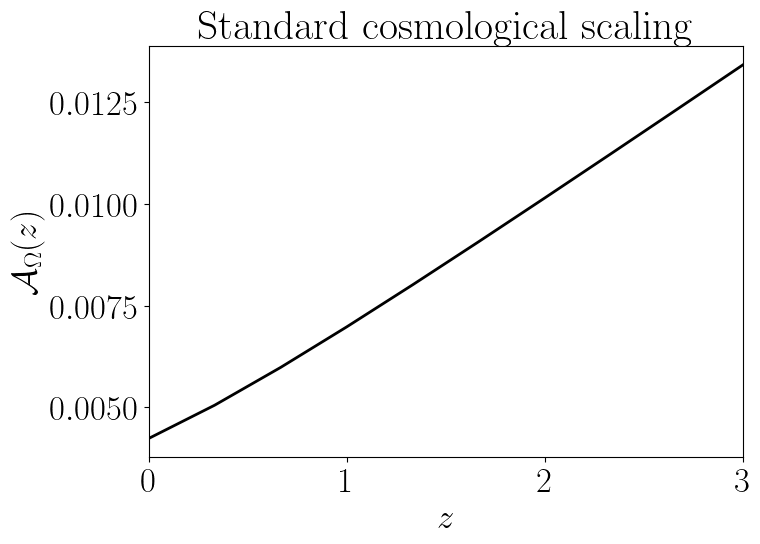

In [20]:
cosmological_factor_grid = cosmological_factor(
    cosmology,
    z_grid,
)

figure, plot = pyplot.subplots(figsize=(8, 6))

plot.plot(
    z_grid,
    cosmological_factor_grid,
    color="black",
    linewidth=2,
)

plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$\mathcal A_\Omega(z)$")
plot.set_title("Standard cosmological scaling")

figure.tight_layout()
pyplot.show()

---

## A shared pivot-redshift coordinate

Define once and use throughout the project

$$
\boxed{r_\ast(z)=\frac{1+z}{1+z_\ast}}.
$$

The additional phenomenological redshift evolution is kept as an explicit factor,

$$
\boxed{
R_z(z;\eta,z_\ast)=r_\ast^\eta(z).
}
$$

- $\eta=0$: no additional evolution;
- $\eta>0$: stronger response at high redshift;
- $\eta<0$: weaker response at high redshift.

The fixed pivot $z_\ast$ controls only the normalization:
$r_\ast(z_\ast)=R_z(z_\ast)=1$ for every $\eta$.

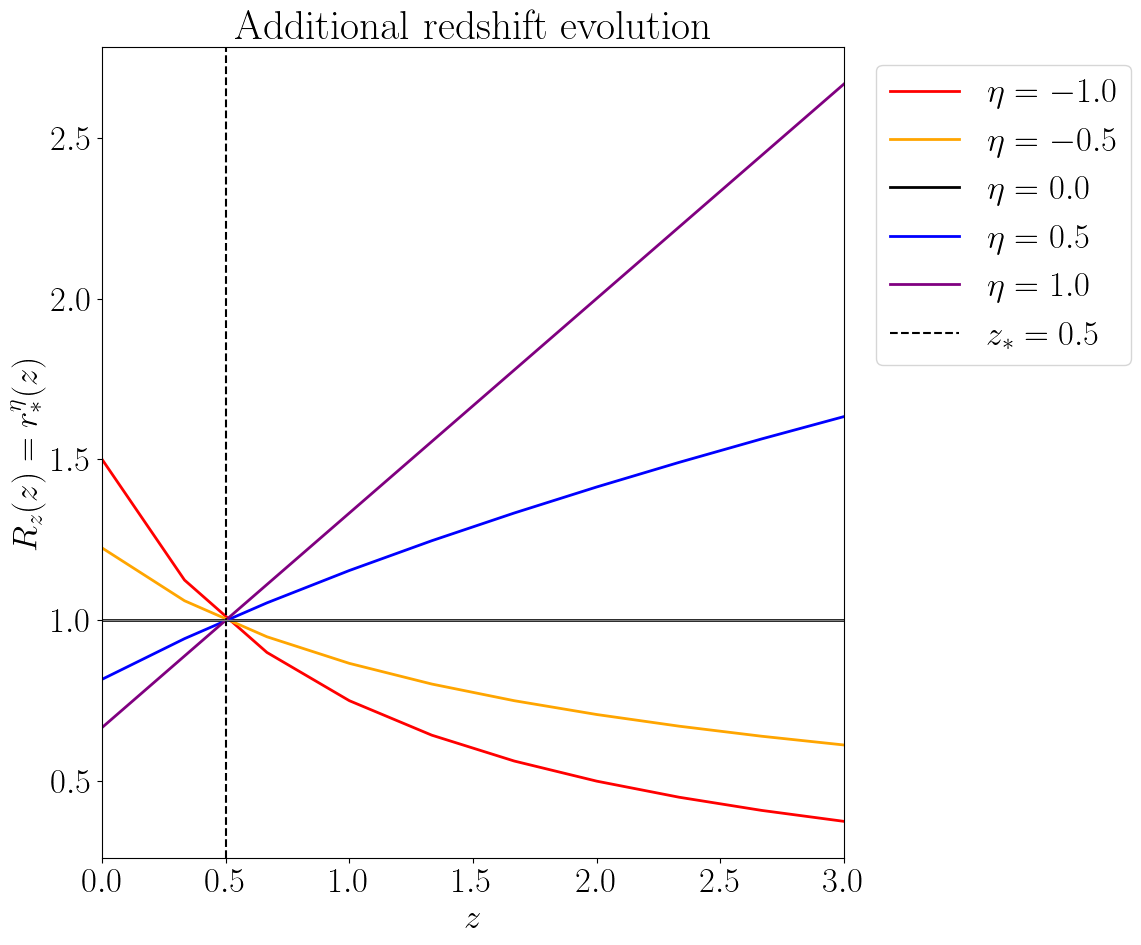

In [9]:
eta_list = [-1.0, -0.5, 0.0, 0.5, 1.0]
colour_list = ["red", "orange", "black", "blue", "purple"]
r_star_grid = pivot_redshift_ratio(z_grid, z_star=Z_STAR)

figure, plot = pyplot.subplots(figsize=(12, 10))

for eta, colour in zip(eta_list, colour_list):
    plot.plot(
        z_grid,
        redshift_factor(z_grid, eta=eta, z_star=Z_STAR),
        color=colour,
        linewidth=2,
        label=rf"$\eta={eta}$",
    )

plot.axvline(
    Z_STAR,
    color="black",
    linestyle="--",
    label=rf"$z_\ast={Z_STAR}$",
)
plot.axhline(1.0, color="grey", linewidth=1)
plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$R_z(z)=r_\ast^\eta(z)$")
plot.set_title("Additional redshift evolution")
plot.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

figure.tight_layout()
pyplot.show()

assert numpy.allclose(
    pivot_redshift_ratio(Z_STAR, z_star=Z_STAR),
    1.0,
)

---

## Smooth luminosity-population evolution

Physically, the luminosity contribution averages over the galaxies in a redshift
bin. A second pure power law would be degenerate with $R_z$, so we use a normalized
smooth transition. Define

$$
r_{q\ast}=r_\ast(z_q)=\frac{1+z_q}{1+z_\ast}.
$$

Then

$$
\boxed{
R_L(z;\xi,s,z_q,z_\ast)
=
\left[
\frac{1+\left(r_\ast(z)/r_{q\ast}\right)^s}
{1+\left(1/r_{q\ast}\right)^s}
\right]^{\xi/s}.
}
$$

| Parameter | Role |
|---|---|
| $\xi$ | Change in logarithmic slope across the transition |
| $s>0$ | Sharpness of the transition |
| $z_q$ | Redshift at the center of the transition |
| $z_\ast$ | Fixed normalization pivot, giving $R_L(z_\ast)=1$ |

Its logarithmic slope is

$$
\frac{d\ln R_L}{d\ln(1+z)}
=
\xi\frac{(r_\ast/r_{q\ast})^s}{1+(r_\ast/r_{q\ast})^s}.
$$

The slope changes smoothly from $0$ below the transition to $\xi$ above it and
equals $\xi/2$ at $z=z_q$. Because $R_z=r_\ast^\eta$ remains explicit, the model
cleanly separates a global redshift trend from this localized population change.

### Guided plotting exercises: luminosity factor

Create **three separate figures**, one for each luminosity parameter. Do not use
subplots. In every figure:

- vary only the parameter named in the exercise;
- hold the other parameters at their stated fiducial values;
- plot a horizontal reference line at $R_L=1$;
- mark the normalization pivot $z_\ast$;
- include axis labels, a descriptive title, and a legend.

Use the existing `z_grid` so that all three figures cover the same redshift range.

#### Explore the slope change $\xi$

Plot $\xi\in\{-2,-1,0,1,2\}$ with $s=2$ and $z_q=1$. Explain how the low- and
high-redshift behavior changes, and identify the curve that removes luminosity
evolution completely.

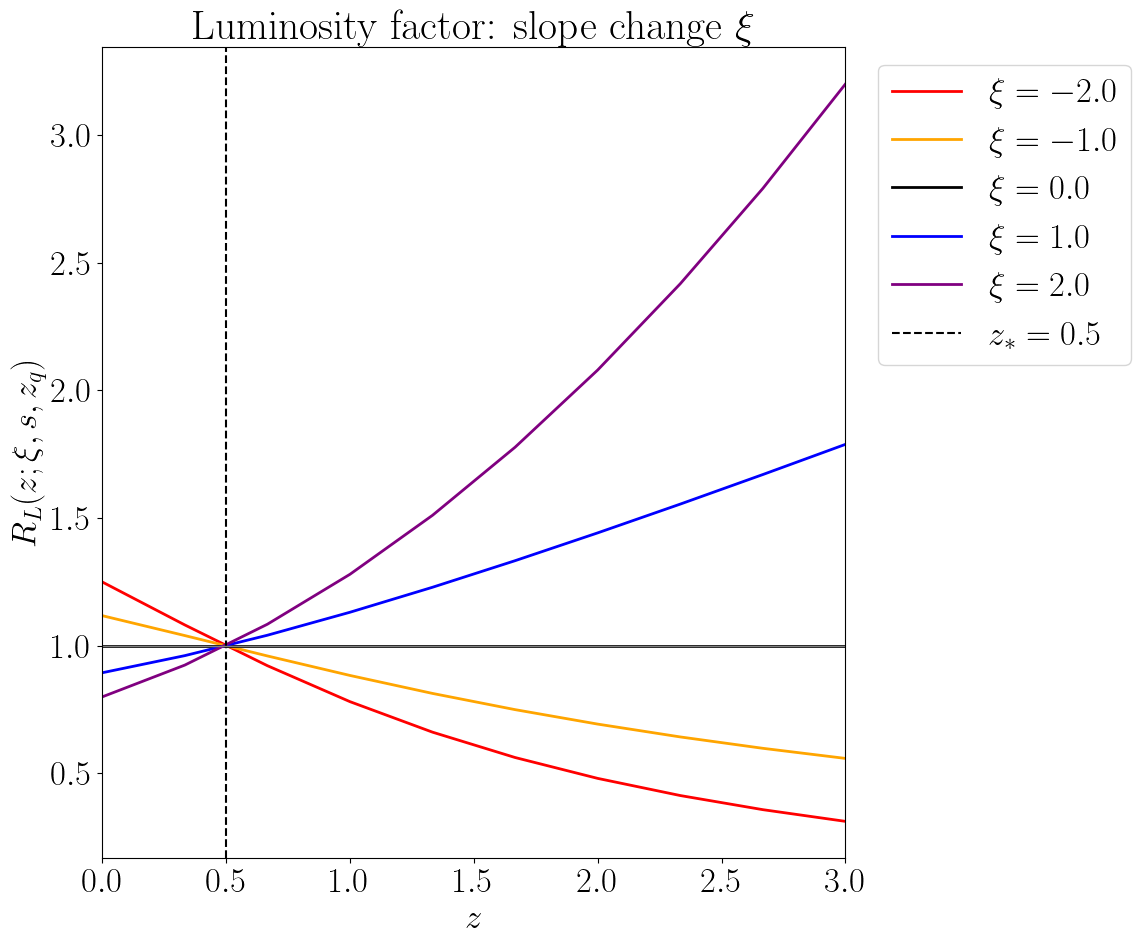

In [10]:
# Student workspace: vary xi and create one luminosity-factor figure.
xi_list = [-2.0, -1.0, 0.0, 1.0, 2.0]
colour_list = ["red", "orange", "black", "blue", "purple"]
s_fixed = 2.0
z_q_fixed = 1.0

# Add your plotting code below.
figure, plot = pyplot.subplots(figsize=(12, 10))

for xi, colour in zip(xi_list, colour_list):
    plot.plot(
        z_grid,
        luminosity_factor(z_grid, xi=xi, s=s_fixed, z_q=z_q_fixed),
        color=colour,
        linewidth=2,
        label=rf"$\xi={xi}$",
    )

plot.axvline(
    Z_STAR,
    color="black",
    linestyle="--",
    label=rf"$z_\ast={Z_STAR}$",
)
plot.axhline(1.0, color="grey", linewidth=1)
plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$R_L(z;\xi,s,z_q)$")
plot.set_title("Luminosity factor: slope change $\\xi$")
plot.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

figure.tight_layout()
pyplot.show()

#### Adjust the transition sharpness $s$

Plot $s\in\{1,2,4,8\}$ with $\xi=1.5$ and $z_q=1$. Explain why the transition
becomes sharper even though the asymptotic change in slope remains $\xi$.

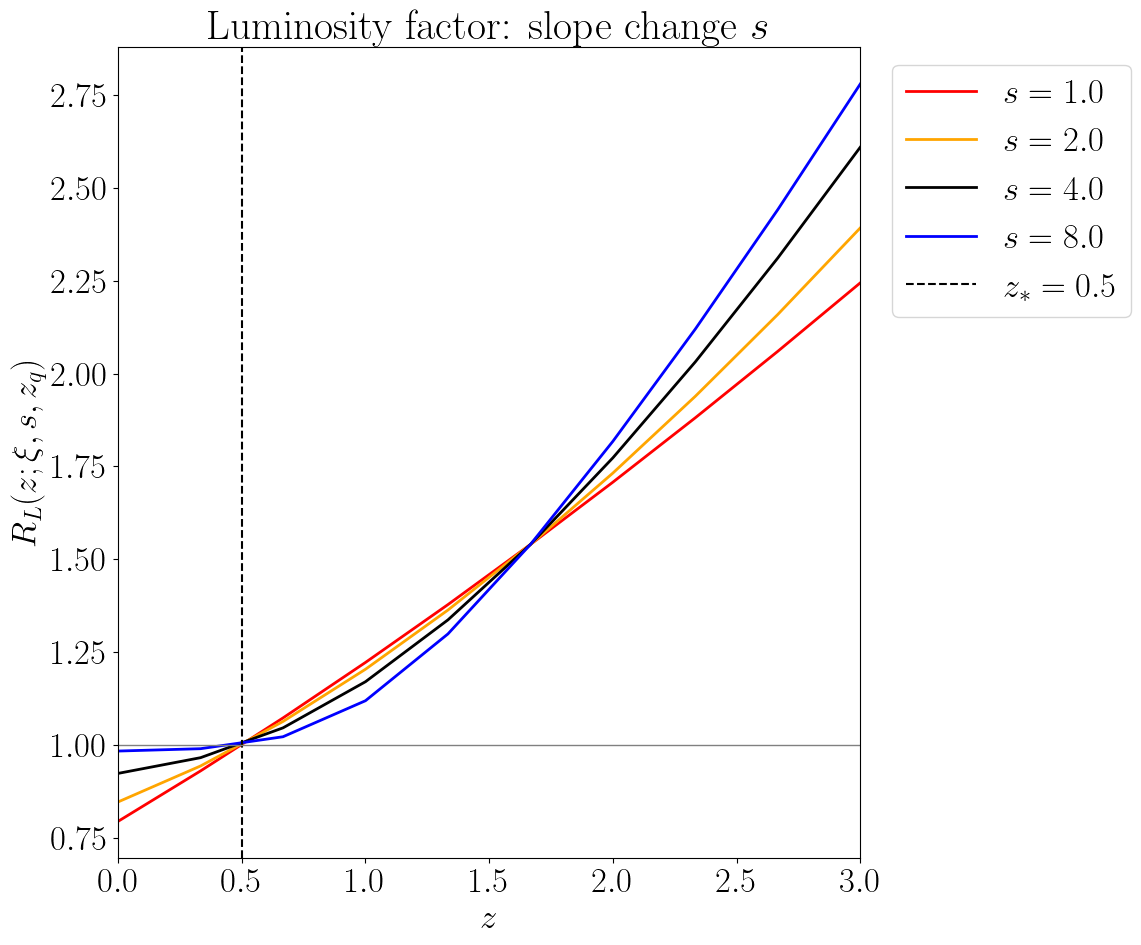

In [11]:
# Student workspace: vary s and create one luminosity-factor figure.
s_list = [1.0, 2.0, 4.0, 8.0]
xi_fixed = 1.5
z_q_fixed = 1.0

# Add your plotting code below.
figure, plot = pyplot.subplots(figsize=(12, 10))

for s, colour in zip(s_list, colour_list):
    plot.plot(
        z_grid,
        luminosity_factor(z_grid, s=s, xi=xi_fixed, z_q=z_q_fixed),
        color=colour,
        linewidth=2,
        label=rf"$s={s}$",
    )

plot.axvline(
    Z_STAR,
    color="black",
    linestyle="--",
    label=rf"$z_\ast={Z_STAR}$",
)
plot.axhline(1.0, color="grey", linewidth=1)
plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$R_L(z;\xi,s,z_q)$")
plot.set_title("Luminosity factor: slope change $s$")
plot.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

figure.tight_layout()
pyplot.show()


#### Move the transition redshift $z_q$

Plot $z_q\in\{0.4,0.8,1.2,1.6\}$ with $\xi=1.5$ and $s=2$. Describe how changing
$z_q$ moves the region where the logarithmic slope changes.

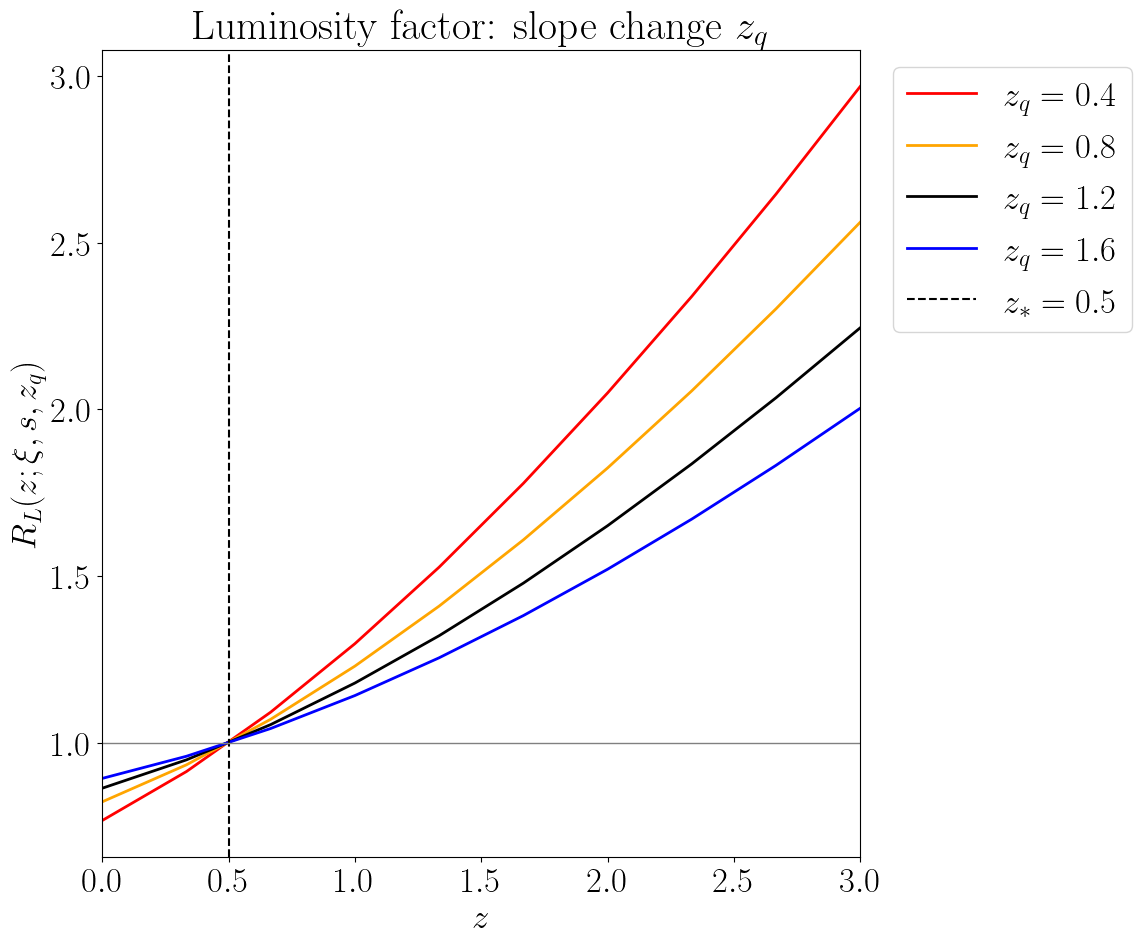

In [12]:
# Student workspace: vary z_q and create one luminosity-factor figure.
z_q_list = [0.4, 0.8, 1.2, 1.6]
xi_fixed = 1.5
s_fixed = 2.0

# Add your plotting code below.
figure, plot = pyplot.subplots(figsize=(12, 10))

for z_q, colour in zip(z_q_list, colour_list):
    plot.plot(
        z_grid,
        luminosity_factor(z_grid, s=s_fixed, xi=xi_fixed, z_q=z_q),
        color=colour,
        linewidth=2,
        label=rf"$z_q={z_q}$",
    )

plot.axvline(
    Z_STAR,
    color="black",
    linestyle="--",
    label=rf"$z_\ast={Z_STAR}$",
)
plot.axhline(1.0, color="grey", linewidth=1)
plot.set_xlim(z1, z2)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$R_L(z;\xi,s,z_q)$")
plot.set_title("Luminosity factor: slope change $z_q$")
plot.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

figure.tight_layout()
pyplot.show()


#### Interpret your luminosity plots

Use your figures to answer the following:

- Why does every curve pass through $R_L=1$ at $z=z_\ast$?
- Why does $\xi=0$ give $R_L(z)=1$ for every $s$ and $z_q$?
- Which parameter changes the asymptotic slope, which moves the transition, and which
  changes only its sharpness?
- When would $s$ and $z_q$ be difficult to constrain from data?

---

## Joint scale and redshift dependence

A constant high-$k$ plateau is too restrictive for nonlinear IA structure. We keep
the model phenomenological and introduce only two simple redshift-evolution indices.
At the pivot redshift, the transition parameters are $k_t^\ast$ and $n^\ast$:

$$
\boxed{k_t(z)=k_t^\ast r_\ast^{\gamma_t}(z)},
\qquad
\boxed{n(z)=n^\ast r_\ast^{\gamma_n}(z)}.
$$

The full response is

$$
\boxed{
S(k,z)
=1+q
\frac{[k/k_t(z)]^{n(z)}}{1+[k/k_t(z)]^{n(z)}}
\left[
\frac{1+[k/k_t(z)]^m}{2}
\right]^{\alpha/m}.
}
$$

The first fraction switches on the nonlinear correction; the last factor allows the
correction to keep changing beyond the transition instead of becoming a constant.

| Parameter | Role |
|---|---|
| $q$ | Strength of the nonlinear correction |
| $k_t^\ast>0$ | Transition wavenumber at $z_\ast$ |
| $n^\ast>0$ | Transition sharpness at $z_\ast$ |
| $\alpha$ | High-$k$ logarithmic slope of the correction |
| $m>0$ | Smoothness of the high-$k$ tail; sampled conservatively over $[1,4]$ |
| $\gamma_t$ | Phenomenological redshift evolution of $k_t$ |
| $\gamma_n$ | Phenomenological redshift evolution of $n$ |

The normalization of the tail factor makes the transition value especially simple:

$$
\boxed{S(k_t(z),z)=1+\frac{q}{2}}.
$$

For $k\gg k_t(z)$,

$$
S(k,z)\simeq
1+q\,2^{-\alpha/m}\left[\frac{k}{k_t(z)}\right]^\alpha.
$$

Thus $\alpha=0$ recovers the earlier plateau $1+q$, while $\alpha\ne0$ permits
a changing nonlinear response. At low $k$, the tail factor approaches a finite
constant, so $n(z)>0$ guarantees $S\to1$. Setting $q=0$ exactly recovers
scale-independent NLA.

In [13]:
logk1 = -4
logk2 = +2
logk_size = 300
k_grid = numpy.logspace(logk1, logk2, logk_size)

### Isolate the scale parameters

The following plots vary one parameter at a time. All calls include a redshift
because the returned Python array `S_k_z` always has shape $(N_z,N_k)$.

#### Change the nonlinear response $q$

Vary $q$ while holding the transition and high-$k$ tail fixed. The $q=0$ curve is
exactly scale-independent NLA.

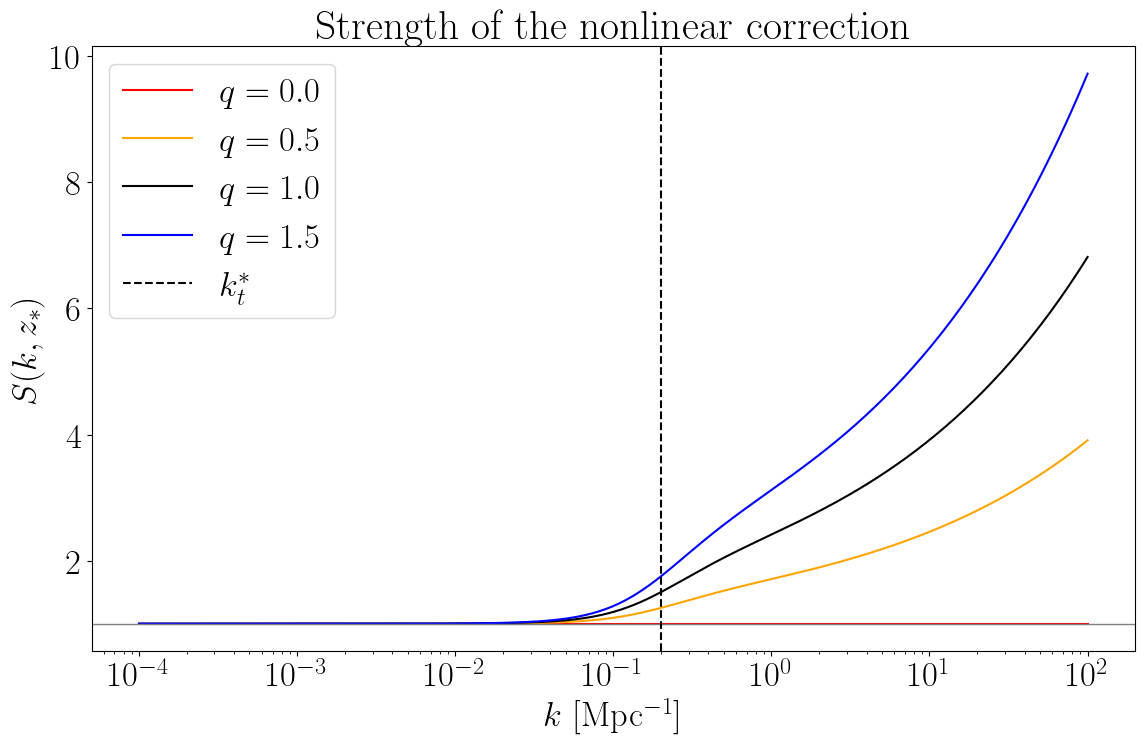

In [14]:
q_list = [0.0, 0.5, 1.0, 1.5]
z_plot = Z_STAR

figure, plot = pyplot.subplots(figsize=(12, 8))

for q, colour in zip(q_list, colour_list):
    S_k_z = scale_transition(
        z_plot,
        k_grid,
        q=q,
        n_star=2.0,
        k_t_star=0.2,
        alpha=0.3,
        m=2.0,
        z_star=Z_STAR,
    )
    plot.plot(k_grid, S_k_z[0], color=colour, label=rf"$q={q}$")

plot.axhline(1.0, color="grey", linewidth=1)
plot.axvline(0.2, color="black", linestyle="--", label=r"$k_t^\ast$")
plot.set_xscale("log")
plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
plot.set_ylabel(r"$S(k,z_\ast)$")
plot.set_title("Strength of the nonlinear correction")
plot.legend()
figure.tight_layout()
pyplot.show()

#### Adjust the pivot sharpness $n^\ast$

Vary $n^\ast\in\{1,2,4\}$ and verify that every curve still crosses
$S=1+q/2$ at $k=k_t^\ast$.

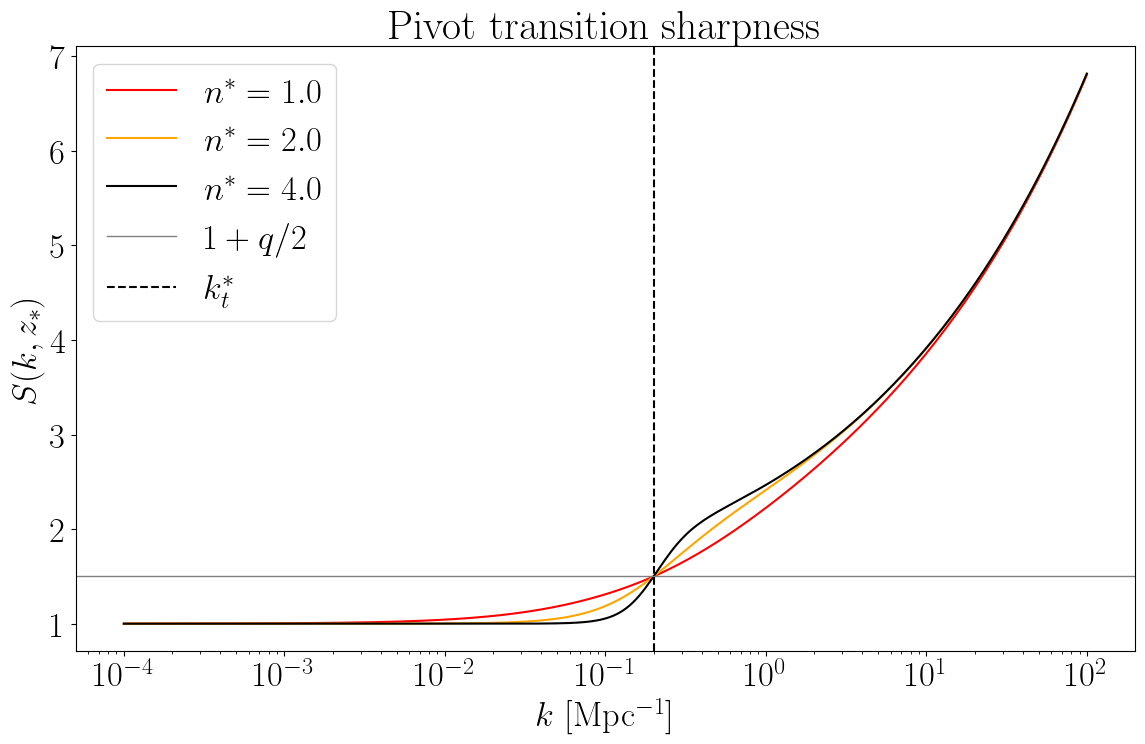

In [15]:
n_star_list = [1.0, 2.0, 4.0]

figure, plot = pyplot.subplots(figsize=(12, 8))

for n_star, colour in zip(n_star_list, colour_list):
    S_k_z = scale_transition(
        Z_STAR,
        k_grid,
        q=1.0,
        n_star=n_star,
        k_t_star=0.2,
        alpha=0.3,
        m=2.0,
        z_star=Z_STAR,
    )
    plot.plot(k_grid, S_k_z[0], color=colour, label=rf"$n^\ast={n_star}$")

plot.axhline(1.5, color="grey", linewidth=1, label=r"$1+q/2$")
plot.axvline(0.2, color="black", linestyle="--", label=r"$k_t^\ast$")
plot.set_xscale("log")
plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
plot.set_ylabel(r"$S(k,z_\ast)$")
plot.set_title("Pivot transition sharpness")
plot.legend()
figure.tight_layout()
pyplot.show()

#### Move the pivot transition scale $k_t^\ast$

Vary $k_t^\ast\in\{0.05,0.2,0.8\}\,\mathrm{Mpc}^{-1}$. This moves both the
switch-on and the start of the high-$k$ tail without changing their normalization.

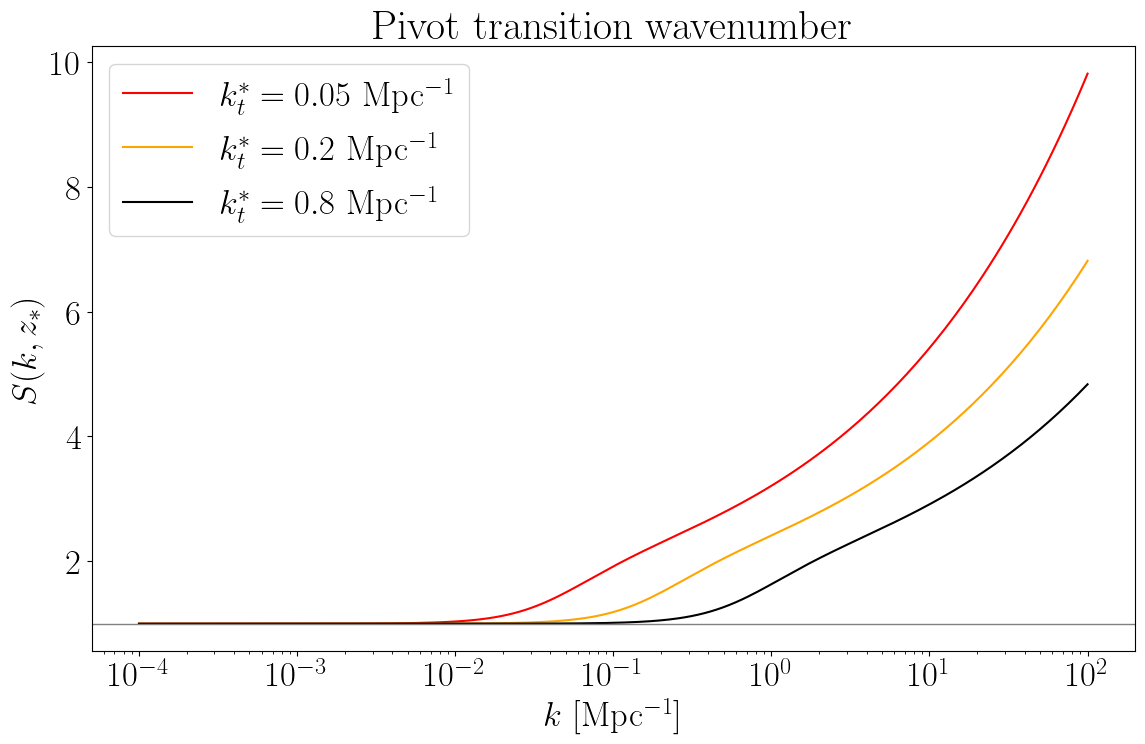

In [16]:
k_t_star_list = [0.05, 0.2, 0.8]

figure, plot = pyplot.subplots(figsize=(12, 8))

for k_t_star, colour in zip(k_t_star_list, colour_list):
    S_k_z = scale_transition(
        Z_STAR,
        k_grid,
        q=1.0,
        n_star=2.0,
        k_t_star=k_t_star,
        alpha=0.3,
        m=2.0,
        z_star=Z_STAR,
    )
    plot.plot(
        k_grid,
        S_k_z[0],
        color=colour,
        label=rf"$k_t^\ast={k_t_star}$ Mpc$^{{-1}}$",
    )

plot.axhline(1.0, color="grey", linewidth=1)
plot.set_xscale("log")
plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
plot.set_ylabel(r"$S(k,z_\ast)$")
plot.set_title("Pivot transition wavenumber")
plot.legend()
figure.tight_layout()
pyplot.show()

#### Change the high-$k$ tail with $\alpha$ and $m$

The slope $\alpha$ controls whether the nonlinear correction grows, stays flat,
or declines. The free parameter $m$ changes how smoothly that tail appears; its
range is deliberately restricted to $1\le m\le4$.

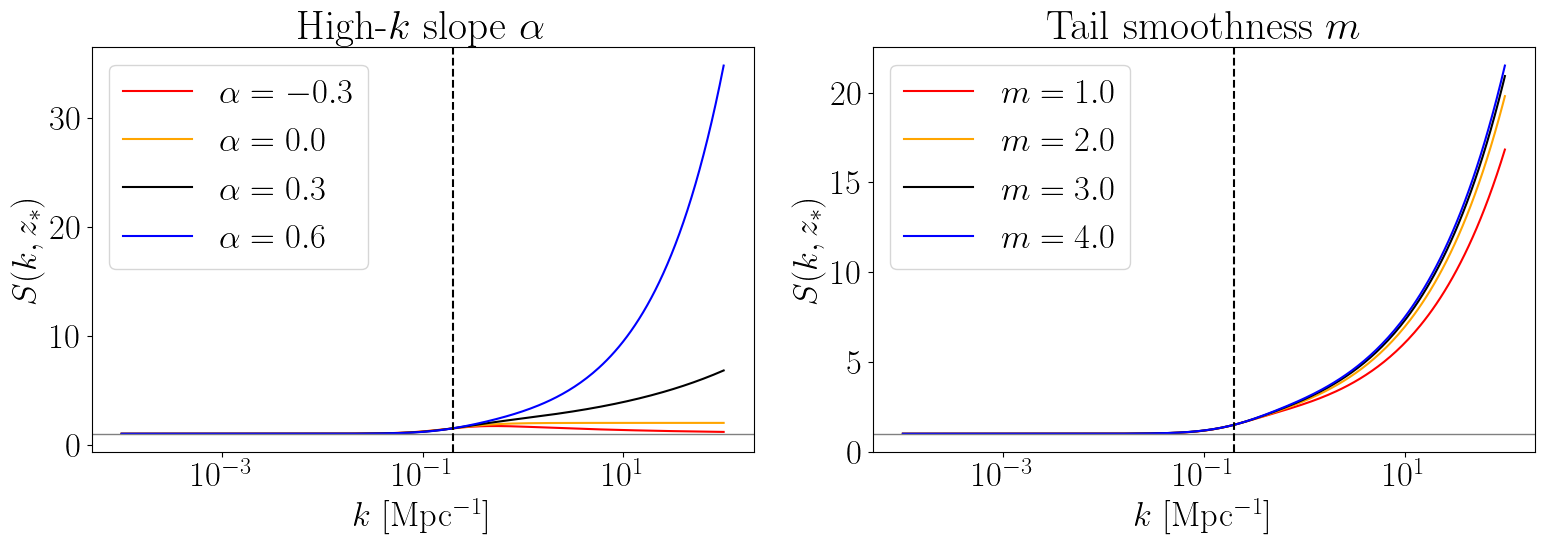

In [17]:
alpha_list = [-0.3, 0.0, 0.3, 0.6]
m_list = [1.0, 2.0, 3.0, 4.0]

figure, axes = pyplot.subplots(1, 2, figsize=(16, 6))

for alpha, colour in zip(alpha_list, colour_list):
    S_k_z = scale_transition(
        Z_STAR, k_grid, q=1.0, n_star=2.0, k_t_star=0.2,
        alpha=alpha, m=2.0, z_star=Z_STAR,
    )
    axes[0].plot(k_grid, S_k_z[0], color=colour, label=rf"$\alpha={alpha}$")

for m, colour in zip(m_list, colour_list):
    S_k_z = scale_transition(
        Z_STAR, k_grid, q=1.0, n_star=2.0, k_t_star=0.2,
        alpha=0.5, m=m, z_star=Z_STAR,
    )
    axes[1].plot(k_grid, S_k_z[0], color=colour, label=rf"$m={m}$")

for axis in axes:
    axis.axhline(1.0, color="grey", linewidth=1)
    axis.axvline(0.2, color="black", linestyle="--")
    axis.set_xscale("log")
    axis.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axis.set_ylabel(r"$S(k,z_\ast)$")
    axis.legend()

axes[0].set_title(r"High-$k$ slope $\alpha$")
axes[1].set_title(r"Tail smoothness $m$")
figure.tight_layout()
pyplot.show()

#### Add modest phenomenological redshift evolution

The indices $\gamma_t$ and $\gamma_n$ do not introduce new physical components.
They simply allow the transition position and sharpness to drift smoothly with
the shared coordinate $r_\ast(z)$.

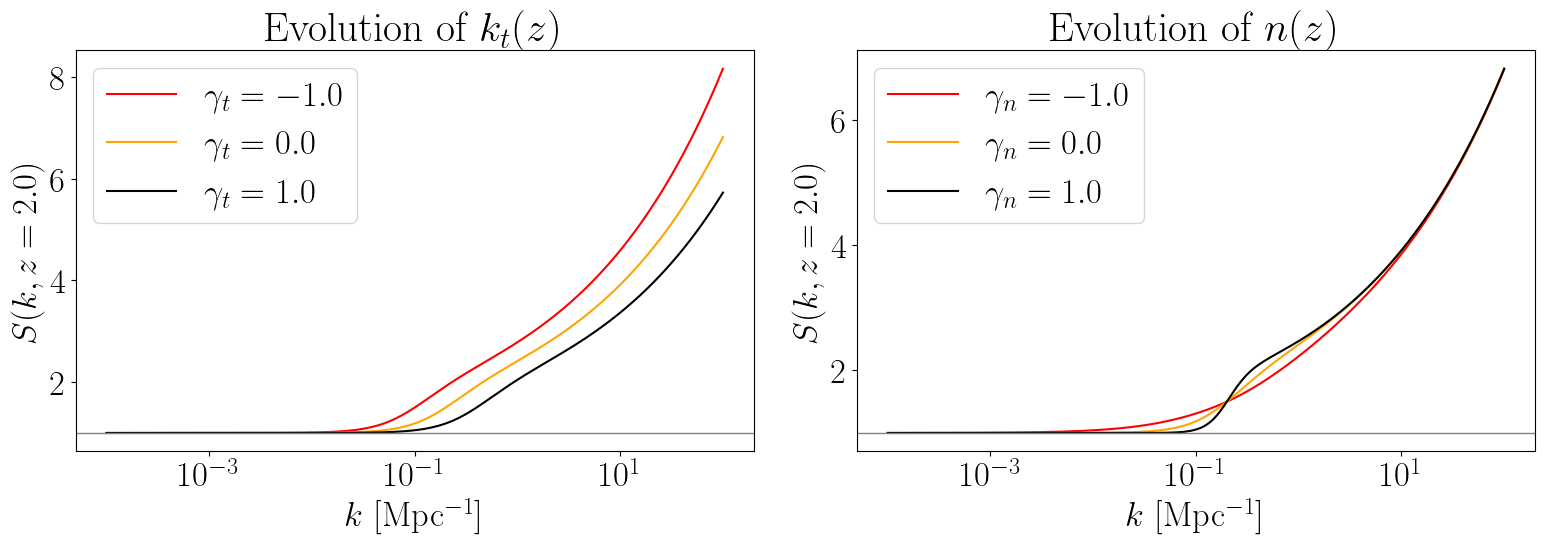

In [18]:
gamma_list = [-1.0, 0.0, 1.0]
z_high = 2.0

figure, axes = pyplot.subplots(1, 2, figsize=(16, 6))

for gamma_t, colour in zip(gamma_list, colour_list):
    S_k_z = scale_transition(
        z_high, k_grid, q=1.0, n_star=2.0, k_t_star=0.2,
        alpha=0.3, m=2.0, gamma_t=gamma_t, gamma_n=0.0,
        z_star=Z_STAR,
    )
    axes[0].plot(k_grid, S_k_z[0], color=colour,
                 label=rf"$\gamma_t={gamma_t}$")

for gamma_n, colour in zip(gamma_list, colour_list):
    S_k_z = scale_transition(
        z_high, k_grid, q=1.0, n_star=2.0, k_t_star=0.2,
        alpha=0.3, m=2.0, gamma_t=0.0, gamma_n=gamma_n,
        z_star=Z_STAR,
    )
    axes[1].plot(k_grid, S_k_z[0], color=colour,
                 label=rf"$\gamma_n={gamma_n}$")

for axis in axes:
    axis.axhline(1.0, color="grey", linewidth=1)
    axis.set_xscale("log")
    axis.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axis.set_ylabel(rf"$S(k,z={z_high})$")
    axis.legend()

axes[0].set_title(r"Evolution of $k_t(z)$")
axes[1].set_title(r"Evolution of $n(z)$")
figure.tight_layout()
pyplot.show()

#### Inspect the complete $S(k,z)$ surface

`NLAModel` is a frozen parameter container whose methods call the same tested
functions used above. The functions remain convenient for derivations; the class
is convenient for sampling, comparison, and reproducible model variants.

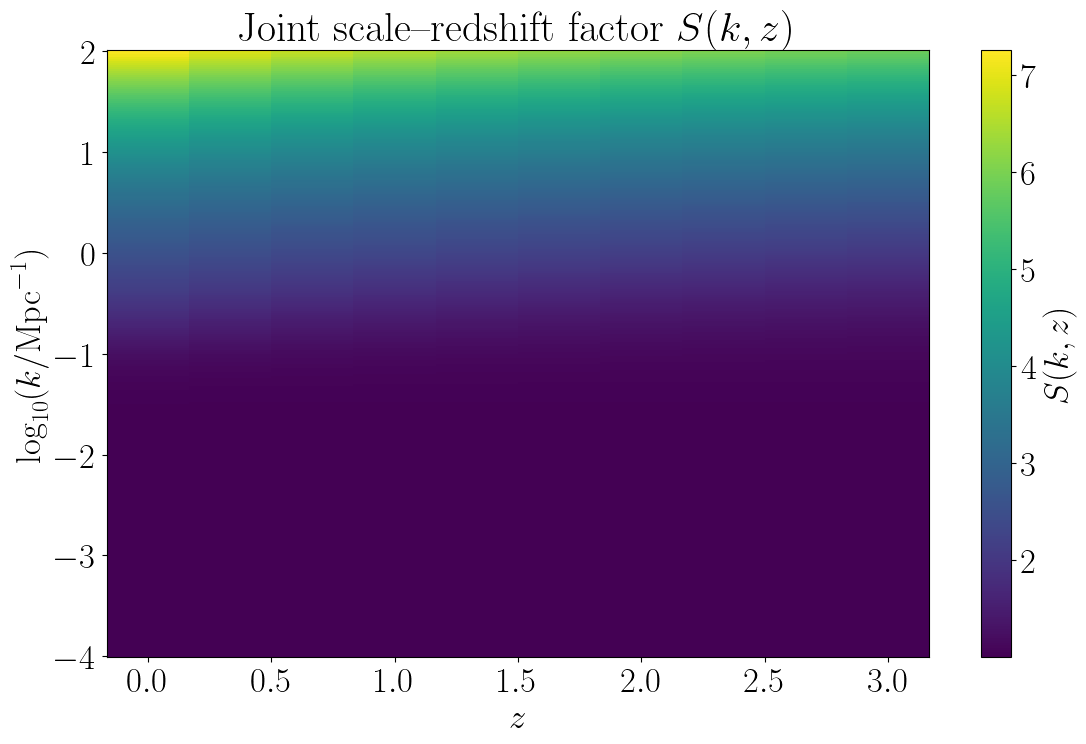

In [19]:
fiducial_model = NLAModel(
    q=1.0,
    n_star=2.0,
    k_t_star=0.2,
    alpha=0.3,
    m=2.0,
    gamma_t=0.6,
    gamma_n=-0.3,
    z_star=Z_STAR,
)

S_k_z = fiducial_model.scale_dependence(z_grid, k_grid)

figure, plot = pyplot.subplots(figsize=(12, 8))
mesh = plot.pcolormesh(
    z_grid,
    numpy.log10(k_grid),
    S_k_z.T,
    shading="auto",
)
plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$\log_{10}(k/{\rm Mpc}^{-1})$")
plot.set_title(r"Joint scale--redshift factor $S(k,z)$")
figure.colorbar(mesh, ax=plot, label=r"$S(k,z)$")
figure.tight_layout()
pyplot.show()

#### Interpret the scale-dependent model

Use the equations and figures to answer:

- Why does $q=0$ give $S(k,z)=1$ everywhere?
- Why is $S(k_t(z),z)=1+q/2$ independent of $\alpha$ and $m$?
- Which parameters control response strength, transition position, transition
  sharpness, high-$k$ slope, and tail smoothness?
- How do $\gamma_t$ and $\gamma_n$ create redshift evolution without adding a new
  physical factor?
- Why should sampled parameters be restricted so $S(k,z)>0$, $n(z)>0$, and
  $k_t(z)>0$ on the training grid?

---

## Check your understanding

Before continuing to `POWER.ipynb`, verify that you can:

- explain the roles of $\mathcal A_\Omega$, the explicit
  $R_z=r_\ast^\eta$, $R_L$, and $S(k,z)$;
- show that $r_\ast(z_\ast)=R_z(z_\ast)=R_L(z_\ast)=1$;
- recover $R_L=1$ when $\xi=0$ and $S=1$ when $q=0$;
- derive $S(k_t(z),z)=1+q/2$ and the high-$k$ slope;
- explain why $m$ is free but conservatively restricted;
- distinguish pivot parameters $k_t^\ast,n^\ast$ from their evolving values
  $k_t(z),n(z)$.

Write a short paragraph answering:

> Why can an evolving luminosity-selected galaxy population imitate physical
> redshift evolution in an intrinsic-alignment measurement?

---

## Continue the workflow

The individual factors are now defined and tested:

- `POWER.ipynb` imports the same functions, recombines them into
  $\mathcal A_\Theta$ and $\mathcal A_{\rm IA}$, and constructs
  $P_{\delta I}$ and $P_{II}$;
- `SAMPLE.ipynb` samples the nuisance and cosmological parameter spaces and stores
  factorized amplitude datasets for later compression or emulation.

Keeping these stages separate makes it easier to diagnose whether an unexpected result
comes from a factor definition, the power-spectrum construction, or the sampling
procedure.

---

## Optional further reading

These papers are not required for completing the notebook:

- [Bridle & King (2007)](https://arxiv.org/abs/0705.0166) introduced the commonly
  used nonlinear-alignment prescription for weak-lensing forecasts.
- [Joachimi et al. (2011)](https://www.aanda.org/articles/aa/pdf/2011/03/aa15621-10.pdf)
  studied observational redshift and luminosity dependence of intrinsic alignments.
- [Blazek et al. (2019)](https://arxiv.org/abs/1708.09247) developed the more physical
  tidal-alignment and tidal-torquing (TATT) framework.

The function $S(k,z)$ used here is a transparent phenomenological interpolation. It
should be calibrated or replaced before scientific parameter inference.